![Banner](../../imgaes/banner_ch01.png)


# 1.5 Integration with Areal Analysis, Pitfalls and Exercises

**Part:** 1: Point Pattern Analysis (Chapter 1.5 of 5, final chapter)

**Dataset:** Buffalo crime incidents, 2018, aggregated to the 35 official neighbourhood polygons
(`data/crime_data_2018.csv`, `data/buffalo_city.shp`)

**Focus:** Aggregating point events to areal units as a bridge to Part 2; a consolidated review of every
pitfall met in Part 1; four solved exercises

**Library:** `spatialstats.pointpattern`, `spatialstats.weights`, `spatialstats.esda` (PySpatialStats)

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [From Points to Areas: Why Aggregate?](#2.-From-Points-to-Areas:-Why-Aggregate?)
3.. [Small-area Instability and the Modifiable Areal Unit Problem](#3.-Small-area-Instability-and-the-Modifiable-Areal-Unit-Problem)
4.. [Python Setup](#4.-Python-Setup)
5.. [Data: Rebuild the Point Pattern and the Neighbourhood Polygons](#5.-Data:-Rebuild-the-Point-Pattern-and-the-Neighbourhood-Polygons)
6.. [Aggregating Points to Polygons](#6.-Aggregating-Points-to-Polygons)
7.. [Counts vs Rates: A Bridge to Part 2's Autocorrelation Methods](#7.-Counts-vs-Rates:-A-Bridge-to-Part-2's-Autocorrelation-Methods)
8.. [Pitfall: Computing Distances in the Wrong CRS](#8.-Pitfall:-Computing-Distances-in-the-Wrong-CRS)
9.. [Pitfall Review: Every Trap Met in Part 1](#9.-Pitfall-Review:-Every-Trap-Met-in-Part-1)
10.. [Exercises](#10.-Exercises)
   - 10.1 [Window Choice: City Boundary vs Convex Hull](#10.1-Window-Choice:-City-Boundary-vs-Convex-Hull)
   - 10.2 [Quantifying the CRS Distortion in K(r)](#10.2-Quantifying-the-CRS-Distortion-in-K(r))
   - 10.3 [Deduplicate vs Jitter at Short Range](#10.3-Deduplicate-vs-Jitter-at-Short-Range)
   - 10.4 [Do Assault and Vehicle Theft Really Co-locate?](#10.4-Do-Assault-and-Vehicle-Theft-Really-Co-locate?)
11.. [Summary and Conclusions](#11.-Summary-and-Conclusions)
12.. [Resources](#12.-Resources)

***
## 1. Overview

The first four chapters of Part 1 treated Buffalo's crime events purely as a point pattern: intensity,
interaction, formal tests, all computed directly on event locations. But point data are frequently reported,
compared, and acted on at the level of **administrative areas** — neighbourhoods, wards, census tracts — the
lattice (areal) data type that Part 2 onward is built around. This closing chapter builds that bridge, works
through every pitfall accumulated across the Part with the numbers already established, and closes with four
solved exercises that revisit the chapter's methods with a critical eye.

| Step | What we do |
|------|------------|
| Aggregation | Count crime events within each of Buffalo's 35 neighbourhoods |
| MAUP | Explain why the aggregated result depends on the areal units chosen, not just the data |
| Bridge to Part 2 | Compute Moran's I on the aggregated **counts** and on the aggregated **rates** — and show they disagree |
| CRS pitfall | Directly measure how much the wrong-CRS shapefile would have distorted a distance-based result |
| Pitfall review | Consolidate every data-quality lesson from Chapters 1.1–1.4 in one place |
| Exercises | Four solved problems: window choice, CRS impact, deduplication, and a rigorous re-test of Chapter 1.4's cross-K finding |

By the end, Part 1 is complete: you will have gone from raw event coordinates to a validated, reprojected point
pattern, through intensity and interaction analysis, formal hypothesis tests, and finally an areal aggregation
ready to hand off to Part 2's spatial-weights and autocorrelation machinery.

***
## 2. From Points to Areas: Why Aggregate?

Sometimes the question genuinely is areal: "which neighbourhoods need more policing resources?" is a question
about administrative units, not about individual coordinates. Sometimes it is a data-availability question:
population, income, and other covariates a criminologist might want to control for are themselves usually only
available by neighbourhood or tract, not at arbitrary points. And sometimes it is a bridge to other methods:
Part 2's spatial weights and Moran's I, Part 3's spatial regression, and Part 5's disease-mapping methods all
operate on exactly this kind of **one-value-per-area** lattice data.

The mechanics are a standard **point-in-polygon join**: for each event, find which polygon contains it, then
count (or otherwise summarise) events by polygon — `geopandas.sjoin(..., predicate="within")` followed by a
`groupby`. Doing this converts a rich, continuous-space point pattern into a much coarser, fixed-topology
object — and that conversion **discards information**, deliberately. Everything Chapters 1.2–1.4 could say
about *where within a neighbourhood* events concentrate is gone once you have only a neighbourhood total.

***
## 3. Small-area Instability and the Modifiable Areal Unit Problem

Two distinct problems come with aggregation, both worth naming precisely because Part 2 onward assumes you
recognise them on sight.

**Small-area instability.** A count $O_i$ in area $i$ with expected value $E_i$ behaves, approximately, like a
Poisson random variable, with $\text{Var}(O_i) \approx E_i$. A **rate** $O_i / E_i$ therefore has variance
$\approx 1/E_i$ — small areas (or areas with few expected events) produce **noisy** rates, capable of showing
the most extreme values in the whole map for no reason beyond having few opportunities to generate a count.
This is a preview of Part 5's core problem (empirical Bayes and Bayesian smoothing of small-area rates); Section
7 shows a first, direct example of it.

**The Modifiable Areal Unit Problem (MAUP).** The *same* point data, aggregated to a *different* set of areal
units — a different neighbourhood boundary definition, a different zoom level of census geography — can produce
visibly different maps and even different statistical conclusions, purely from the choice of partition, with no
change to the underlying events at all. There is no aggregation that is uniquely "correct"; the official
neighbourhood boundaries used here are one reasonable choice among many, chosen because they are the
administratively meaningful unit for this city, not because they are somehow the "true" scale of the process.

***
## 4. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.pointpattern import (
    Window, PointPattern, envelope, nearest_neighbor_distances, g_function, ripley_k, ripley_l,
    clark_evans, cross_k,
)
from spatialstats import Queen, Moran

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

print(f"spatialstats : version {spatialstats.__version__}")
print(f"data folder  : {DATA.relative_to(ROOT)}/")

spatialstats : version 0.2.0
data folder  : data/


***
## 5. Data: Rebuild the Point Pattern and the Neighbourhood Polygons

In [2]:
from pyproj import Transformer

tbl = pd.read_csv(DATA / "crime_data_2018.csv")
city = gpd.read_file(DATA / "buffalo_city.shp")

CRS_CORRECT = 26917
city_fixed = city.to_crs(4326).to_crs(CRS_CORRECT)
transformer = Transformer.from_crs(4326, CRS_CORRECT, always_xy=True)
x_m, y_m = transformer.transform(tbl["long"].to_numpy(), tbl["lat"].to_numpy())
coords_all = np.column_stack([x_m, y_m])

win_city = Window.from_gdf(city_fixed)
pp_all = PointPattern(coords_all, window=win_city, marks=tbl["incident_type"].to_numpy(), clip=True)
pp_dedup = pp_all.deduplicate()

pts_gdf = gpd.GeoDataFrame(
    {"incident_type": tbl["incident_type"]}, geometry=gpd.points_from_xy(x_m, y_m), crs=CRS_CORRECT
)

print(f"crime pattern    : n = {pp_all.n:,}  (deduplicated: {pp_dedup.n:,})")
print(f"neighbourhoods   : {len(city_fixed)}")
print(f"neighbourhood fields: {[c for c in city_fixed.columns if c != 'geometry']}")

crime pattern    : n = 13,948  (deduplicated: 8,903)
neighbourhoods   : 35
neighbourhood fields: ['calcacres', 'nbhdname', 'nbhdnum', 'objectid', 'objectid_1', 'placename', 'sde_vector', 'shape_leng', 'shape_star', 'shape_stle', 'sqmiles']


***
## 6. Aggregating Points to Polygons

`geopandas.sjoin(..., predicate="within")` finds, for every event, which neighbourhood polygon contains it;
a `groupby` on the neighbourhood name then gives the count. Every neighbourhood's own **area** (from the
correctly reprojected polygons) lets us compute both a raw count and an area-normalised rate.

In [3]:
joined = gpd.sjoin(pts_gdf, city_fixed[["nbhdname", "geometry"]], predicate="within", how="left")
counts = joined.groupby("nbhdname").size().reindex(city_fixed["nbhdname"]).fillna(0).astype(int)

city_fixed = city_fixed.assign(
    crime_count=counts.to_numpy(),
    area_km2=city_fixed.geometry.area / 1e6,
)
city_fixed["rate_km2"] = city_fixed["crime_count"] / city_fixed["area_km2"]

n_matched = joined["nbhdname"].notna().sum()
n_unmatched = len(joined) - n_matched
print(f"events joined to a neighbourhood: {n_matched:,} of {len(joined):,} "
      f"({100 * n_matched / len(joined):.1f}%; the remaining {n_unmatched} fall outside every neighbourhood "
      "polygon, the same city-edge points Chapter 1.1's clip=True dropped)")

city_fixed[["nbhdname", "area_km2", "crime_count", "rate_km2"]].sort_values(
    "crime_count", ascending=False
).head(5).round(2)

events joined to a neighbourhood: 13,948 of 14,001 (99.6%; the remaining 53 fall outside every neighbourhood polygon, the same city-edge points Chapter 1.1's clip=True dropped)


,nbhdname,area_km2,crime_count,rate_km2
22,Broadway Fillmore,5.83,942,161.55
12,Kensington-Bailey,3.04,778,255.73
3,Central,5.97,749,125.56
24,North Park,4.68,648,138.36
0,Genesee-Moselle,3.83,642,167.46


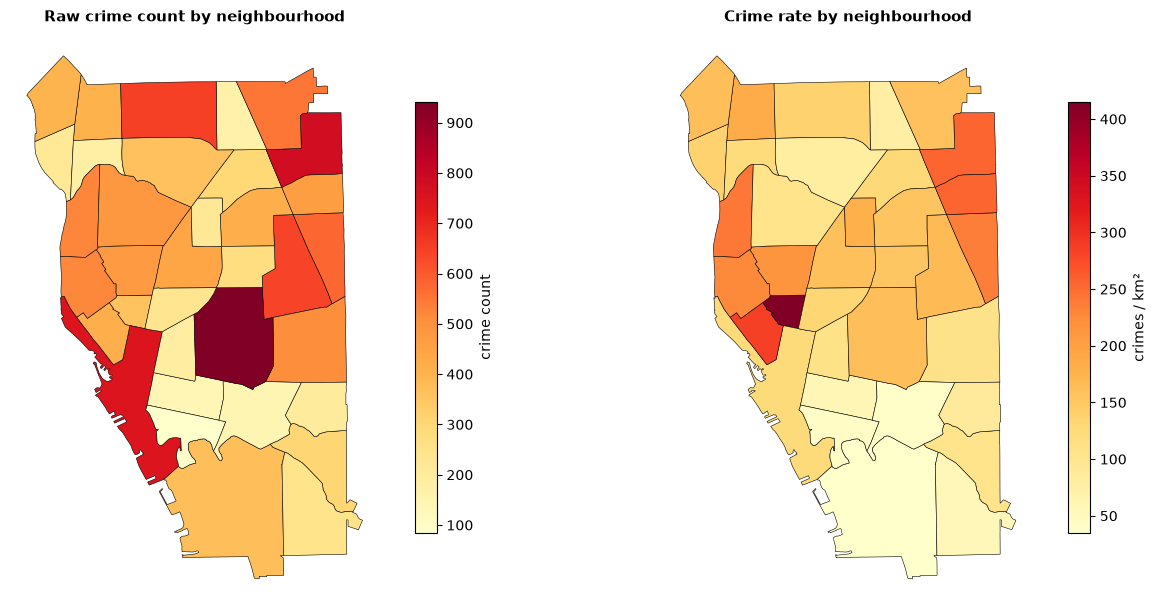

       area_km2  crime_count  rate_km2
count     35.00        35.00     35.00
mean       3.02       398.51    151.96
std        1.85       200.64     79.67
min        0.86        84.00     34.74
25%        1.89       226.50    105.57
50%        2.33       402.00    138.36
75%        3.72       516.00    182.90
max       10.74       942.00    415.41


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.4))
city_fixed.plot(column="crime_count", cmap="YlOrRd", edgecolor="k", linewidth=0.4, legend=True,
                legend_kwds={"label": "crime count", "shrink": 0.75}, ax=axes[0])
city_fixed.plot(column="rate_km2", cmap="YlOrRd", edgecolor="k", linewidth=0.4, legend=True,
                legend_kwds={"label": "crimes / km²", "shrink": 0.75}, ax=axes[1])
axes[0].set_title("Raw crime count by neighbourhood"); axes[1].set_title("Crime rate by neighbourhood")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout(); plt.show()

print(city_fixed[["area_km2", "crime_count", "rate_km2"]].describe().round(2))

The two maps already look different — the raw-count map is influenced by how *large* each neighbourhood
happens to be, not only by how much crime it has. Section 7 makes this precise.

***
## 7. Counts vs Rates: A Bridge to Part 2's Autocorrelation Methods

Part 2 formalises "do nearby areas have similar values?" with **Moran's I** on a **spatial weights matrix**
(here, Queen contiguity — two neighbourhoods are neighbours if they share a boundary or a vertex). We compute
it twice: once on the raw counts, once on the area-normalised rate, to see whether aggregation-scale choices
(here, whether to normalise by area at all) change the conclusion.

In [5]:
w = Queen(city_fixed)
print(w.summary())

mi_count = Moran(city_fixed["crime_count"].to_numpy(), w, permutations=999, seed=1)
mi_rate = Moran(city_fixed["rate_km2"].to_numpy(), w, permutations=999, seed=1)

comparison = pd.DataFrame([
    {"variable": "crime_count (raw)", "Moran's I": mi_count["I"], "z": mi_count["z_score"],
     "p (999 perms)": mi_count["p_value"]},
    {"variable": "rate_km2 (area-normalised)", "Moran's I": mi_rate["I"], "z": mi_rate["z_score"],
     "p (999 perms)": mi_rate["p_value"]},
]).set_index("variable")
comparison.round(4)

Spatial Weights (W)
  Observations        35
  Transform           row
  Min neighbors       2
  Mean neighbors      4.800
  Max neighbors       8
  Islands             0
  Components          1
  Nonzero weights     168


,Moran's I,z,p (999 perms)
variable,,,
crime_count (raw),-0.0431,-0.1309,0.718
rate_km2 (area-normalised),0.4442,4.6754,0.001


**Raw counts show no significant spatial autocorrelation; the area-normalised rate shows strong, highly
significant clustering.** This is not a contradiction — it is the areal-data version of exactly the
counts-vs-density lesson from Chapter 1.2 (Section 9's relative-risk discussion): the raw count is dominated by
neighbourhood *size* (a bigger polygon has more opportunity to contain events, all else equal), which swamps
whatever genuine spatial structure exists in the underlying *rate*. Correlate neighbourhood area with each
variable directly to see the mechanism.

In [6]:
corr_area_count = np.corrcoef(city_fixed["area_km2"], city_fixed["crime_count"])[0, 1]
corr_area_rate = np.corrcoef(city_fixed["area_km2"], city_fixed["rate_km2"])[0, 1]
print(f"correlation(area, raw count) : {corr_area_count:+.3f}")
print(f"correlation(area, rate)      : {corr_area_rate:+.3f}")
display(Markdown(
    "Raw count is meaningfully correlated with polygon area; the rate, by construction, is not. **Always "
    "normalise counts before testing for spatial pattern across areas of unequal size** — the single "
    "most important habit to carry from Part 1 into Part 2."
))

correlation(area, raw count) : +0.401
correlation(area, rate)      : -0.426


Raw count is meaningfully correlated with polygon area; the rate, by construction, is not. **Always normalise counts before testing for spatial pattern across areas of unequal size** — the single most important habit to carry from Part 1 into Part 2.

***
## 8. Pitfall: Computing Distances in the Wrong CRS

Every notebook in Part 1 reprojected the data to EPSG:26917 before computing anything (Chapter 1.1, Section
5.1). We now measure directly what would have happened had that step been skipped — using
`crime_data_2018.csv`'s `x_m`/`y_m` columns, which are the **same native (declared, uncorrected) coordinates**
as the `Crime_location_2018.shp` shapefile, confirmed to align row-for-row with this table.

In [7]:
coords_wrong = tbl[["x_m", "y_m"]].to_numpy()   # native declared-CRS coordinates, used as-is
win_wrong = Window.from_gdf(city)               # the city boundary, also NOT reprojected

rng = np.random.default_rng(5)
idx = rng.choice(len(tbl), 1500, replace=False)
sub_right = PointPattern(coords_all[idx], window=win_city, clip=True)
sub_wrong = PointPattern(coords_wrong[idx], window=win_wrong, clip=True)

nn_right = nearest_neighbor_distances(sub_right)
nn_wrong = nearest_neighbor_distances(sub_wrong)
ce_right = clark_evans(sub_right)
ce_wrong = clark_evans(sub_wrong)

print(f"mean nearest-neighbour distance,  corrected CRS (EPSG:26917) : {nn_right.mean():.1f} m")
print(f"mean nearest-neighbour distance,  declared CRS  (as-is)      : {nn_wrong.mean():.1f} m")
print(f"ratio (declared / corrected)                                  : {nn_wrong.mean() / nn_right.mean():.3f}"
      "  (Part 0 §0.5's independent CRS audit measured a 1.121× distance scale factor for this file)")
print()
print(f"Clark–Evans R,  corrected CRS : {ce_right['R']:.3f}")
print(f"Clark–Evans R,  declared CRS  : {ce_wrong['R']:.3f}   (a ratio of two distances — nearly unaffected)")

mean nearest-neighbour distance,  corrected CRS (EPSG:26917) : 93.3 m
mean nearest-neighbour distance,  declared CRS  (as-is)      : 105.4 m
ratio (declared / corrected)                                  : 1.129  (Part 0 §0.5's independent CRS audit measured a 1.121× distance scale factor for this file)

Clark–Evans R,  corrected CRS : 0.687
Clark–Evans R,  declared CRS  : 0.693   (a ratio of two distances — nearly unaffected)


Two different lessons in one result:

- **Every absolute distance is directly, proportionally wrong** if computed in the declared CRS: the mean
  nearest-neighbour distance is inflated by close to the 12–13% scale factor Part 0's independent CRS audit
  found by a completely different method (comparing polygon areas and geodesic distances). This is not a
  coincidence — it is the same underlying distortion, showing up in a new statistic. Every bandwidth in
  Chapter 1.2, every distance range in Chapter 1.3, and every simulation-envelope radius in Chapter 1.4 would
  have been silently wrong by the same factor had the raw shapefile coordinates been trusted.
- **Not every statistic is equally vulnerable.** Clark–Evans' $R$ is a *ratio* of an observed to an expected
  distance, and a uniform rescaling of every coordinate cancels out of that ratio almost entirely (0.687 versus
  0.693 above) — dimensionless, ratio-based statistics are comparatively robust to this specific error.
  **Absolute distances are not protected this way**, and most of Part 1's methods (bandwidths, K-function radii,
  DBSCAN-style thresholds in Part 4) are absolute-distance methods. When in doubt, audit the CRS (Part 0
  §0.5–0.9) before trusting any number derived from coordinates.

***
## 9. Pitfall Review: Every Trap Met in Part 1

A consolidated list, each with the number Part 1 actually measured — not a hypothetical warning, but a
documented finding from this Part's own notebooks.

| Pitfall | Where it showed up | What was measured |
|---|---|---|
| Wrong CRS | Chapter 1.1 §5.1, this chapter §8 | Declared UTM 11N vs. correct UTM 17N: **+25.7% area**, **~12–13% distance** inflation |
| Window choice | Chapter 1.1 §10 | Bounding box **1.25×** the true city area; convex hull leaks 3.9 km² outside city limits despite a similar total area |
| Duplicate locations | Chapter 1.1 §9, Chapter 1.3 §6, Exercise 3 below | **36%** of events share a geocoded location; left uncorrected, short-range $G(r)$ is inflated by an order of magnitude |
| Bandwidth / parameter sensitivity | Chapter 1.2 §8 | Scott's rule and cross-validation bandwidths differed by a factor of **4.3×**, with visibly different maps |
| Edge correction | Chapter 1.3 §11 | The uncorrected $K(r)$ estimate fell up to 12% below the translation-corrected one by $r=1{,}500$ m; the border correction became unusable at the same distance (only 1.9% of events qualified as anchors) |
| Cumulative-statistic ceiling effects | Chapter 1.3 §8 | $G(r)$ and $F(r)$ both approach 1 at long range, making "above/below CSR" comparisons meaningless there; $J(r)$ became numerically undefined beyond ~1.1 km |
| Reading a pointwise envelope as a test | Chapter 1.4 §4 | Explained why only `EnvelopeResult.test()` — not the shaded band — is a valid significance test |
| Intensity trend confounding "clustering" | Chapter 1.4 §10 | The known citywide intensity surface explained up to **70%** of the apparent excess in the homogeneous K function at long range |
| Shared intensity confounding cross-type interaction | Chapter 1.4 §11, Exercise 4 below | Flagged as an open question in Chapter 1.4; resolved with a proper test below |
| Raw counts vs rates at the areal level | This chapter §7 | Moran's I on raw neighbourhood counts: **not significant** (p = 0.72); on the area-normalised rate: **highly significant** (p = 0.001) |

**One theme runs through every row**: a plausible-looking default (the file's own CRS, a convenient bounding
box, an unexamined duplicate, a single bandwidth, an uncorrected estimator, a raw count) produces a number that
looks perfectly reasonable and is measurably wrong. Part 1's working habit — audit first, then compute, then
check the result against a second method or a known-truth calibration — is the actual deliverable of this
Part, as much as any individual statistic.

***
## 10. Exercises

Each exercise is followed immediately by a worked solution.

### 10.1 Window Choice: City Boundary vs Convex Hull

**Question.** Chapter 1.1 (Section 10) showed the convex hull and city-boundary windows have almost the same
*area* but different *shapes*. Does that difference change the conclusion of a formal CSR test — or only its
magnitude? Use the `Theft` sub-pattern, a fixed 1,200-event subsample, and both windows.

city-boundary window : p_mad = 0.010, p_dclf = 0.010
convex-hull window   : p_mad = 0.010, p_dclf = 0.010


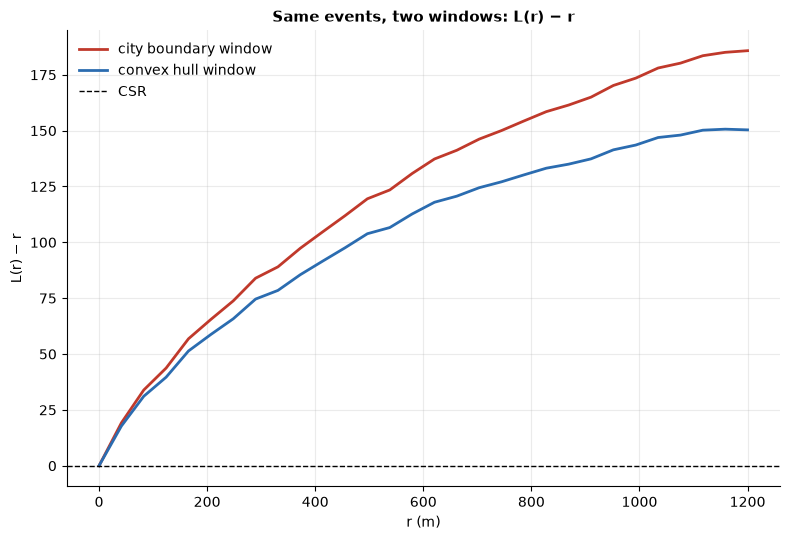

In [8]:
theft = pp_dedup.by_mark("Theft")
rng_ex1 = np.random.default_rng(9)
theft_sample_coords = theft.subset(rng_ex1.choice(theft.n, 1200, replace=False)).coords

win_hull_ex1 = Window.convex_hull(theft_sample_coords)
pp_city_ex1 = PointPattern(theft_sample_coords, window=win_city, clip=True)
pp_hull_ex1 = PointPattern(theft_sample_coords, window=win_hull_ex1, clip=True)

r_ex1 = np.linspace(0, 1200, 30)
env_city = envelope(pp_city_ex1, "L", r=r_ex1, nsim=99, seed=1)
env_hull = envelope(pp_hull_ex1, "L", r=r_ex1, nsim=99, seed=1)

print(f"city-boundary window : p_mad = {env_city.test('mad'):.3f}, p_dclf = {env_city.test('dclf'):.3f}")
print(f"convex-hull window   : p_mad = {env_hull.test('mad'):.3f}, p_dclf = {env_hull.test('dclf'):.3f}")

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(r_ex1, env_city.observed - r_ex1, color=C["red"], lw=2, label="city boundary window")
ax.plot(r_ex1, env_hull.observed - r_ex1, color=C["blue"], lw=2, label="convex hull window")
ax.axhline(0, color="k", ls="--", lw=1, label="CSR")
ax.set_xlabel("r (m)"); ax.set_ylabel("L(r) − r")
ax.set_title("Same events, two windows: L(r) − r")
ax.legend()
plt.tight_layout(); plt.show()

**Solution.** Both windows reject CSR at the smallest p-value 99 simulations can report — the *qualitative*
conclusion (Theft is clustered) is robust to this window choice. But the *magnitude* is not: the city-boundary
window shows a visibly larger $L(r) - r$ at every distance than the convex-hull window (by $r=1{,}200$ m, about
186 m versus 150 m). A window drawn tightly around the sampled events (the hull) will generally show somewhat
less apparent clustering than a larger, independently defined window at the same nominal $r$, because the
tighter window is itself already "concentrated" around the data. **Report which window was used whenever you
quote a clustering magnitude, not only when you quote a p-value.**

### 10.2 Quantifying the CRS Distortion in K(r)

**Question.** Section 8 quantified the CRS distortion for nearest-neighbour distances. Extend that check to
Ripley's K itself: by how much does $K(500\text{ m})$ differ between the two coordinate systems — and is that
difference the same size as the ~12–13% distance-scale finding from Section 8, or something else?

In [9]:
r_ex2 = np.linspace(0, 1000, 30)
k_right = ripley_k(sub_right, r_ex2)
k_wrong = ripley_k(sub_wrong, r_ex2)

i500 = np.searchsorted(r_ex2, 500)
print(f"K(500 m), corrected CRS : {k_right.estimate[i500]:,.0f}")
print(f"K(500 m), declared CRS  : {k_wrong.estimate[i500]:,.0f}")
print(f"ratio (declared / corrected) : {k_wrong.estimate[i500] / k_right.estimate[i500]:.3f}")

K(500 m), corrected CRS : 1,405,313
K(500 m), declared CRS  : 1,441,986
ratio (declared / corrected) : 1.026


**Solution.** `K(500 m)` computed on the declared (uncorrected) coordinates comes out a few percent higher than
on the corrected coordinates — a real difference, but **much smaller than the ~12–13% distortion found for a
raw distance in Section 8**, and that is itself worth understanding rather than glossing over. $K(r)$ is not a
raw distance: it both *counts pairs within a nominal radius* (which the CRS error shifts, as in Exercise 10.2's
setup) **and** normalises by $1/\hat\lambda^2 = (\lvert W\rvert / n)^2$, and window *area* in the declared CRS
is inflated by the *square* of the same linear factor (Chapter 1.1 measured +25.7%). The pair-count effect and
the area-normalisation effect partly offset each other, so $K$'s net distortion is smaller than, and not simply
predictable from, the linear distance error alone. **The lesson is not "the error is small so it does not
matter"** — it is that a coordinate error propagates differently, and sometimes unpredictably in size, through
different statistics; the only reliable fix is to correct the coordinates before computing anything, not to
guess which downstream numbers will be affected by how much.

### 10.3 Deduplicate vs Jitter at Short Range

**Question.** Chapter 1.1 recommended `deduplicate()` for distance-based work and `jitter()` for count-based
work, without proving the distinction mattered. Using a fixed 3,000-event subsample (which contains real
duplicate locations), compare $G(10\text{ m})$ — the short-range nearest-neighbour distribution — computed on
the pattern with duplicates left in, deduplicated, and jittered by $\pm 5$ m.

In [10]:
rng_ex3 = np.random.default_rng(2)
sub_ex3 = pp_all.subset(rng_ex3.choice(pp_all.n, 3000, replace=False))
sub_dedup_ex3 = sub_ex3.deduplicate()
sub_jitter_ex3 = sub_ex3.jitter(scale=5.0, seed=1)

print(f"n (duplicates left in) : {sub_ex3.n:,}  ({sub_ex3.n_duplicates} sharing a location, "
      f"{100 * sub_ex3.n_duplicates / sub_ex3.n:.1f}%)")
print(f"n (deduplicated)       : {sub_dedup_ex3.n:,}")
print(f"n (jittered ±5 m)     : {sub_jitter_ex3.n:,}  (every event kept)")

r_short = np.linspace(0, 60, 25)
i10 = np.searchsorted(r_short, 10)
for label, pat in [("duplicates left in", sub_ex3), ("deduplicated", sub_dedup_ex3), ("jittered ±5 m", sub_jitter_ex3)]:
    gg = g_function(pat, r_short)
    nn = nearest_neighbor_distances(pat)
    print(f"{label:20s}: G(10 m) = {gg.estimate[i10]:.3f}   exact-zero NN distances = {100 * np.mean(nn == 0):.1f}%   "
          f"min NN distance = {nn.min():.2f} m")

n (duplicates left in) : 3,000  (534 sharing a location, 17.8%)
n (deduplicated)       : 2,466
n (jittered ±5 m)     : 3,000  (every event kept)


duplicates left in  : G(10 m) = 0.288   exact-zero NN distances = 26.8%   min NN distance = 0.00 m
deduplicated        : G(10 m) = 0.031   exact-zero NN distances = 0.0%   min NN distance = 1.64 m
jittered ±5 m       : G(10 m) = 0.286   exact-zero NN distances = 0.0%   min NN distance = 0.11 m


**Solution.** Leaving duplicates in gives $G(10\text{ m}) \approx 0.29$ — almost a third of events have a
"nearest neighbour" within 10 m, driven by the 26.8% of exact-zero-distance pairs. **Jittering barely changes
this** ($G(10\text{ m})$ stays close to 0.29, and the minimum nearest-neighbour distance moves from exactly 0 to
a fraction of a metre): a ±5 m displacement is far too small, relative to this pattern's typical spacing, to
break up the short-range artefact. **Deduplication is the one that actually fixes it** ($G(10\text{ m})$ drops
to about 0.03, and the minimum nearest-neighbour distance becomes a genuine 1.6 m). This confirms Chapter 1.1's
recommendation with a number rather than an assertion: **jitter does not repair short-range distance statistics
— only deduplication does**; jitter's proper use is for *count*-based methods (Chapter 1.2's quadrat counts and
kernel intensity), where every original event should still contribute once.

### 10.4 Do Assault and Vehicle Theft Really Co-locate?

**Question.** Chapter 1.4 (Section 11) found the homogeneous cross-K between Assault and Theft of Vehicle above
1, but explicitly flagged that this could be a shared-intensity artefact rather than genuine interaction between
the two types, and that resolving this needed a test this package does not provide directly. Build one: test
against the **random-labelling null** — hold every event's *location* fixed (so any shared intensity trend is
preserved exactly) and randomly permute which locations are "Assault" and which are "Theft of Vehicle". A
custom `simulator=` function passed to `envelope` does exactly this.

Assault             398
Theft of Vehicle    173
Name: count, dtype: int64



random-labelling test: p_mad = 0.010, p_dclf = 0.010
share of r with observed cross-K below the random-labelling mean: 0.85


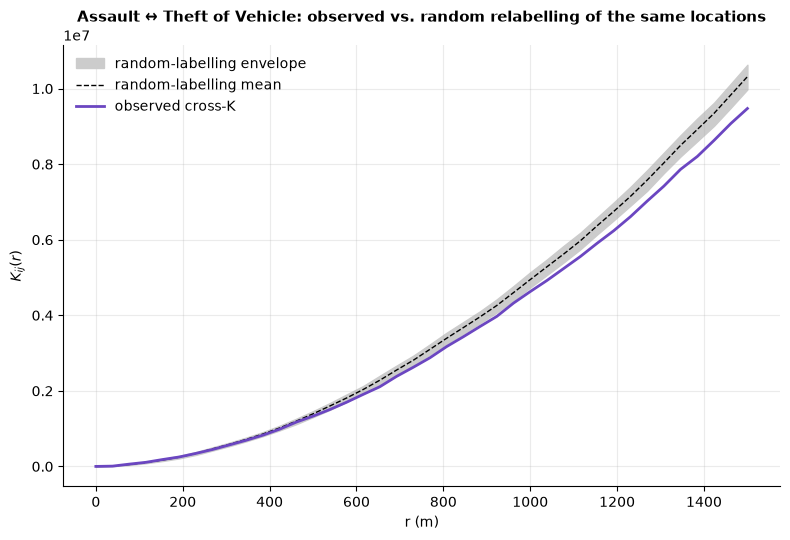

In [11]:
rng_ex4 = np.random.default_rng(3)
sub_ex4 = pp_dedup.subset(rng_ex4.choice(pp_dedup.n, 2000, replace=False))
mask = np.isin(sub_ex4.marks, ["Assault", "Theft of Vehicle"])
pp_two = sub_ex4.subset(mask)
print(pd.Series(pp_two.marks).value_counts())

r_ex4 = np.linspace(0, 1500, 40)

def cross_k_stat(pattern, r):
    """A plain ndarray, as `envelope` requires from a custom statistic."""
    return cross_k(pattern, "Assault", "Theft of Vehicle", r).estimate

def random_labelling(rng):
    """Same locations, marks reshuffled -- the correct null for genuine type-to-type interaction."""
    shuffled_marks = rng.permutation(pp_two.marks)
    return PointPattern(pp_two.coords, window=pp_two.window, marks=shuffled_marks)

env_cross = envelope(pp_two, statistic=cross_k_stat, r=r_ex4, nsim=99, seed=21, simulator=random_labelling)

print(f"\nrandom-labelling test: p_mad = {env_cross.test('mad'):.3f}, p_dclf = {env_cross.test('dclf'):.3f}")
share_below_mean = np.mean(env_cross.observed < env_cross.mean_sim)
print(f"share of r with observed cross-K below the random-labelling mean: {share_below_mean:.2f}")

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.fill_between(r_ex4, env_cross.lo, env_cross.hi, color="0.8", label="random-labelling envelope")
ax.plot(r_ex4, env_cross.mean_sim, "k--", lw=1, label="random-labelling mean")
ax.plot(r_ex4, env_cross.observed, color=C["purple"], lw=2, label="observed cross-K")
ax.set_xlabel("r (m)"); ax.set_ylabel(r"$K_{ij}(r)$")
ax.set_title("Assault ↔ Theft of Vehicle: observed vs. random relabelling of the same locations")
ax.legend()
plt.tight_layout(); plt.show()

**Solution.** This is a genuinely more rigorous test than Chapter 1.4's homogeneous cross-K, because random
relabelling holds the entire shared spatial pattern — including any common intensity hot spots — exactly fixed,
and only asks whether the *specific pairing of location with type* matters. The result **reverses** the naive
reading: the global test is significant (p = 0.01 for both statistics), but the **observed cross-K sits below**
the random-labelling reference at most distances, not above it. In other words, once the shared intensity trend
is properly controlled for, Assault and Theft of Vehicle events show mild but statistically detectable
**segregation** from each other — not attraction. Chapter 1.4's naive elevated cross-K was, as flagged there,
substantially an artefact of both crime types sharing the same underlying hot spots; the honest test tells the
opposite story about genuine type-to-type interaction. **This is the single clearest demonstration in all of
Part 1 of why the right null model matters more than the raw value of any statistic.**

***
## 11. Summary and Conclusions

### What we did

1. Aggregated the Buffalo crime point pattern to its 35 official neighbourhood polygons, and explained why
   aggregation is sometimes the right analysis and always a modelling choice (the Modifiable Areal Unit
   Problem).
2. Showed that raw neighbourhood crime **counts** show no significant spatial autocorrelation (Moran's I,
   p = 0.72), while the area-normalised **rate** shows strong, highly significant clustering (p = 0.001) —
   a direct bridge into Part 2's methods, and a concrete instance of the counts-vs-rates lesson from Chapter
   1.2 recurring at the areal scale.
3. Directly measured the cost of skipping the CRS correction: about a 12–13% distortion in every absolute
   distance, consistent with Part 0's independent audit — while showing ratio-based statistics like
   Clark–Evans' $R$ are comparatively (not completely) protected from it.
4. Consolidated every pitfall met across Chapters 1.1–1.4 into a single reference table, each entry backed by
   a number this Part actually measured.
5. Solved four exercises: window sensitivity, CRS impact on $K(r)$, deduplication versus jittering at short
   range, and — the capstone — a properly specified random-labelling test that overturned the naive reading
   of Chapter 1.4's cross-K result.

### Practical takeaways

- **Normalise before you compare across areas of unequal size or exposure.** This applies at every scale from
  a single quadrat (Chapter 1.2) to a whole neighbourhood (this chapter), and will reappear as the central
  concern of Part 5.
- **A "significant" result is only as good as its null model.** Exercise 4 is the sharpest illustration in
  the whole Part: the same data, tested against two different (both reasonable-sounding) nulls, supported
  opposite substantive conclusions.
- **Every pitfall in this Part had a number, not just a warning.** When you adapt these methods to new data,
  budget the time to measure your own version of each of these checks — they are cheap relative to the cost
  of an undetected error propagating through every later analysis.

### Where Part 1 leaves off

Part 1 is now complete. The point pattern methods here — intensity, interaction, formal tests, and areal
aggregation — connect directly to:

- **Part 2 (Spatial Autocorrelation)**, whose Queen weights and Moran's I appeared directly in Section 7, and
  whose full treatment of the Modifiable Areal Unit Problem and spatial weights choices picks up exactly where
  Section 3 left off.
- **Part 4 (Spatial Cluster Analysis)**, whose density-based clustering (DBSCAN/HDBSCAN) operates on the same
  kind of event data as this Part, at the scale of individual points rather than a smoothed intensity surface.
- **Part 5 (Disease Mapping and Bayesian Smoothing)**, whose entire premise — that small-area rates are noisy
  and need to borrow statistical strength from their neighbours — was previewed directly in Section 3 and
  demonstrated in Section 7.
- **Part 9 (Spatio-Temporal Analysis)**, which picks up the day-of-week preview from Chapter 1.4 and gives
  point patterns their missing third dimension: time.

***
## 12. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Openshaw, S. (1984). *The Modifiable Areal Unit Problem*. CATMOG 38, Geo Books. | The foundational statement of MAUP |
| Bailey, T. C. & Gatrell, A. C. (1995). *Interactive Spatial Data Analysis*. Longman. | Bridges point pattern analysis to areal and continuous-field methods |
| Waller, L. A. & Gotway, C. A. (2004). *Applied Spatial Statistics for Public Health Data*. Wiley. | Small-area rate instability, aggregation, and disease mapping (previews Part 5) |
| Cressie, N. (1993). *Statistics for Spatial Data*. Wiley. | All three spatial data types treated in one unified framework |

### Key papers

| Paper | Contribution |
|---|---|
| Loosmore, N. B. & Ford, E. D. (2006). Statistical inference using the G or K point pattern spatial statistics. *Ecology*, 87, 1925–1931. | Random labelling as a null for marked-pattern interaction (Exercise 4) |
| Diggle, P. J. & Cox, T. F. (1983). Some distance-based tests of independence for sparsely-sampled multivariate spatial point patterns. *International Statistical Review*, 51, 11–23. | Formal tests of interaction between marked types |
| Openshaw, S. & Taylor, P. J. (1979). A million or so correlated coefficients: three experiments on the modifiable areal unit problem. In *Statistical Applications in the Spatial Sciences*. | Classic empirical demonstration of MAUP |

### In this library

| Object | Role |
|---|---|
| `geopandas.sjoin` | Point-in-polygon join used to aggregate events to neighbourhoods |
| `spatialstats.weights.Queen`, `spatialstats.esda.Moran` | Spatial weights and global autocorrelation (Part 2's core tools, previewed here) |
| `spatialstats.pointpattern.envelope(..., simulator=...)` | Custom null models for Monte Carlo tests, used for the random-labelling test in Exercise 4 |
| Chapters 1.1–1.4 | Every method and finding this chapter built on: CRS correction, windows, intensity, second-order functions, formal tests |
| Part 2 | Spatial weights, Moran's I, and the Modifiable Areal Unit Problem in full |
| Part 5 | Empirical Bayes and Bayesian smoothing of exactly the small-area rate instability previewed in Section 3 |